## Entorno

### Dependencias

In [1]:
!pip install ultralytics
!pip install onnx
!pip install imgaug
!pip install albumentations==1.3.0
!pip install opencv-python
!pip install pybboxes
!pip install fiftyone
!pip install gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 975.7 kB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_6

In [2]:
import pandas as pd
import numpy as np
import re
import cv2
import torch
import locale
from collections import Counter
import random

import seaborn as sns
import matplotlib.pyplot as plt

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from google.colab import drive as dri
from oauth2client.client import GoogleCredentials

import sys
import os
import zipfile
import shutil
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from ultralytics import YOLO

import fiftyone as fo
import fiftyone.zoo as foz

### Device

In [3]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return
        len(self.dl)

device = get_default_device()
device

device(type='cpu')

### Autenticacion

In [4]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

dri.mount('/content/drive')

Mounted at /content/drive


## Dataset

### Descarga

In [22]:
!unzip /content/drive/MyDrive/carta_base.zip -d /content/dataset

Archive:  /content/drive/MyDrive/carta_base.zip
  inflating: /content/dataset/images/train/46094_Mateo_Rovere_2.png  
  inflating: /content/dataset/images/train/s56189_salvador_sanchez_174.png  
  inflating: /content/dataset/images/train/58491_fabio_giampaoli_13.png  
  inflating: /content/dataset/images/train/f37478_santiago_ferrero_04.png  
  inflating: /content/dataset/images/train/L32425_eugenio_lopez_09.png  
  inflating: /content/dataset/images/train/s56804_alexis_segui_17.png  
  inflating: /content/dataset/images/train/fed41586e4af6462681da0eab7d26de9.png  
  inflating: /content/dataset/images/train/S57061_Leandro_Salvana_18.png  
  inflating: /content/dataset/images/train/51659_antonio_peroni_05.png  
  inflating: /content/dataset/images/train/52256_daniel_ponce_25.png  
  inflating: /content/dataset/images/train/S57061_Leandro_Salvana_21.png  
  inflating: /content/dataset/images/train/L32425_eugenio_lopez_08.png  
  inflating: /content/dataset/images/train/P_51977_martin_per

## Analisis

### Clases

In [ ]:
CLASSES = [
    "1O", "1C", "1E", "1B",
    "2O", "2C", "2E", "2B",
    "3O", "3C", "3E", "3B",
    "4O", "4C", "4E", "4B",
    "5O", "5C", "5E", "5B",
    "6O", "6C", "6E", "6B",
    "7O", "7C", "7E", "7B",
    "8O", "8C", "8E", "8B",
    "9O", "9C", "9E", "9B",
    "10O", "10C", "10E", "10B",
    "11O", "11C", "11E", "11B",
    "12O", "12C", "12E", "12B",
    "J"
]

train_labels_path = "/content/dataset/labels/train"
val_labels_path = "/content/dataset/labels/val"
train_images_path = "/content/dataset/images/train"
val_images_path = "/content/dataset/images/val"

In [ ]:
# Lista para almacenar los paths de archivos fuera de rango
invalid_files = []

def count_classes_in_folder(folder_path, image_folder_path):
    class_counter = Counter()

    # Recorre todos los archivos en la carpeta
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.txt'):
            file_path = os.path.join(folder_path, file_name)
            with open(file_path, 'r') as file:
                for line in file:
                    if line.strip():
                        parts = line.split()
                        if len(parts) > 0:
                            try:
                                class_index = int(parts[0])
                                if 0 <= class_index < len(CLASSES):
                                    class_name = CLASSES[class_index]
                                    class_counter[class_name] += 1
                                else:
                                    print(f"Índice fuera de rango: {class_index} en archivo {file_name}")
                                    invalid_files.append(file_path)
                            except ValueError:
                                print(f"Índice no es un entero válido: {parts[0]} en archivo {file_name}")
                                invalid_files.append(file_path)

    # Elimina archivos inválidos y sus correspondientes imágenes
    for invalid_file in invalid_files:
        image_file = os.path.join(image_folder_path, os.path.basename(invalid_file).replace('.txt', '.png'))
        try:
            os.remove(invalid_file)
            os.remove(image_file)
            print(f"Eliminados {invalid_file} y {image_file}")
        except OSError as e:
            print(f"Error al eliminar archivos: {e}")

    sorted_class_counts = dict(sorted(class_counter.items()))
    return sorted_class_counts

def plot_class_distribution(class_counts, title, color):
    sorted_class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))
    labels = list(sorted_class_counts.keys())
    sizes = list(sorted_class_counts.values())

    sns.set(style="white")

    plt.figure(figsize=(14, 3))
    bars = plt.bar(labels, sizes, color=color, edgecolor='black')

    plt.title(title)
    plt.xticks(rotation=90)

    for bar, size in zip(bars, sizes):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), size, ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

Índice fuera de rango: 49 en archivo g5845_gravifiorino_27.txt
Índice fuera de rango: 51 en archivo gravifiorino_1.txt
Índice fuera de rango: 49 en archivo 43237686_Constantino_Ferrucci_17.txt
Índice fuera de rango: 50 en archivo gravifiorino_7.txt
Índice fuera de rango: 49 en archivo 293cf3fc96a4dbd5d6004436ddc39b48.txt
Índice fuera de rango: 49 en archivo 58491_fabio_giampaoli_21.txt
Índice fuera de rango: 49 en archivo 77ab1ff6c01ac3fed7cebfe404efce8c.txt
Eliminados /content/dataset/labels/train/g5845_gravifiorino_27.txt y /content/dataset/images/train/g5845_gravifiorino_27.png
Eliminados /content/dataset/labels/train/gravifiorino_1.txt y /content/dataset/images/train/gravifiorino_1.png
Eliminados /content/dataset/labels/train/43237686_Constantino_Ferrucci_17.txt y /content/dataset/images/train/43237686_Constantino_Ferrucci_17.png
Eliminados /content/dataset/labels/train/gravifiorino_7.txt y /content/dataset/images/train/gravifiorino_7.png
Eliminados /content/dataset/labels/train/29

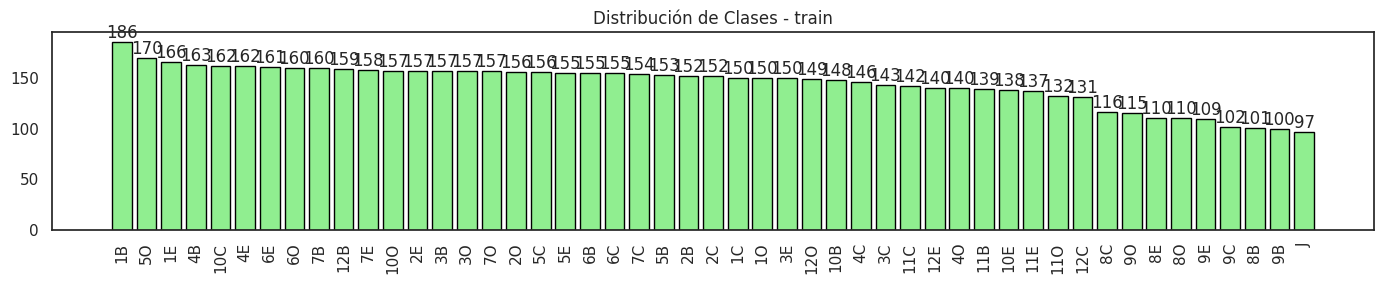

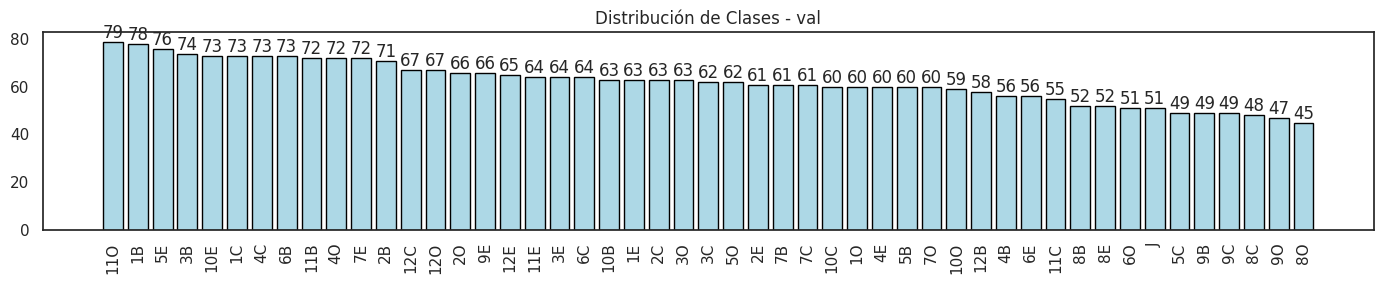

In [ ]:
# Contar las clases en las carpetas
class_counts_1 = count_classes_in_folder(train_labels_path, train_images_path)
class_counts_2 = count_classes_in_folder(val_labels_path, val_images_path)

# Graficar los resultados
plot_class_distribution(class_counts_1, "Distribución de Clases - train", color='lightgreen')
plot_class_distribution(class_counts_2, "Distribución de Clases - val", color='lightblue')

### Undersampling

In [ ]:
def get_class_counts(folder_path):
    class_counter = Counter()
    file_class_mapping = {}

    for file_name in os.listdir(folder_path):
        if file_name.endswith('.txt'):
            file_path = os.path.join(folder_path, file_name)
            with open(file_path, 'r') as file:
                for line in file:
                    if line.strip():
                        parts = line.split()
                        if len(parts) > 0:
                            try:
                                class_index = int(parts[0])
                                class_counter[class_index] += 1
                                if class_index not in file_class_mapping:
                                    file_class_mapping[class_index] = []
                                file_class_mapping[class_index].append(file_name)
                            except ValueError:
                                continue

    return class_counter, file_class_mapping

def undersample_classes(folder_path, image_folder_path, target_samples):
    class_counter, file_class_mapping = get_class_counts(folder_path)

    for class_index, file_list in file_class_mapping.items():
        if len(file_list) > target_samples:
            files_to_remove = random.sample(file_list, len(file_list) - target_samples)
            for file_name in files_to_remove:
                label_file_path = os.path.join(folder_path, file_name)
                image_file_path = os.path.join(image_folder_path, file_name.replace('.txt', '.png'))

                try:
                    os.remove(label_file_path)
                    os.remove(image_file_path)
                    print(f"Removed {label_file_path} and {image_file_path}")
                except OSError as e:
                    print(f"Error removing files: {e}")

In [ ]:
# Get class counts in the training folders
train_class_counts, _ = get_class_counts(train_labels_path)
median_train_samples = int(np.median(list(train_class_counts.values())))

# Get class counts in the validation folders
val_class_counts, _ = get_class_counts(val_labels_path)
median_val_samples = int(np.median(list(val_class_counts.values())))

In [ ]:
median_train_samples, median_val_samples

(150, 62)

In [ ]:
# Undersample the classes
undersample_classes(train_labels_path, train_images_path, median_train_samples)
undersample_classes(val_labels_path, val_images_path, median_val_samples)

Removed /content/dataset/labels/train/64191_Sofia_BrizuelaCipolletti_18.txt and /content/dataset/images/train/64191_Sofia_BrizuelaCipolletti_18.png
Removed /content/dataset/labels/train/w05576_juan_wagner_02.txt and /content/dataset/images/train/w05576_juan_wagner_02.png
Removed /content/dataset/labels/train/s56189_salvador_sanchez_177.txt and /content/dataset/images/train/s56189_salvador_sanchez_177.png
Removed /content/dataset/labels/train/A45161_Fabian_Aguirre_28.txt and /content/dataset/images/train/A45161_Fabian_Aguirre_28.png
Removed /content/dataset/labels/train/51705_micaela_pozzo_21.txt and /content/dataset/images/train/51705_micaela_pozzo_21.png
Removed /content/dataset/labels/train/03531_mirian_yanez_20.txt and /content/dataset/images/train/03531_mirian_yanez_20.png
Removed /content/dataset/labels/train/03531_mirian_yanez_05.txt and /content/dataset/images/train/03531_mirian_yanez_05.png
Removed /content/dataset/labels/train/46019_taiel_raffaeli_28.txt and /content/dataset/i

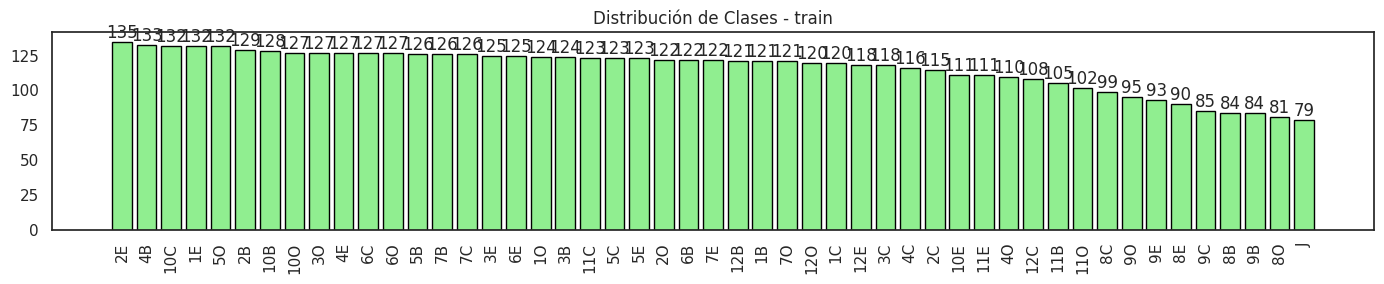

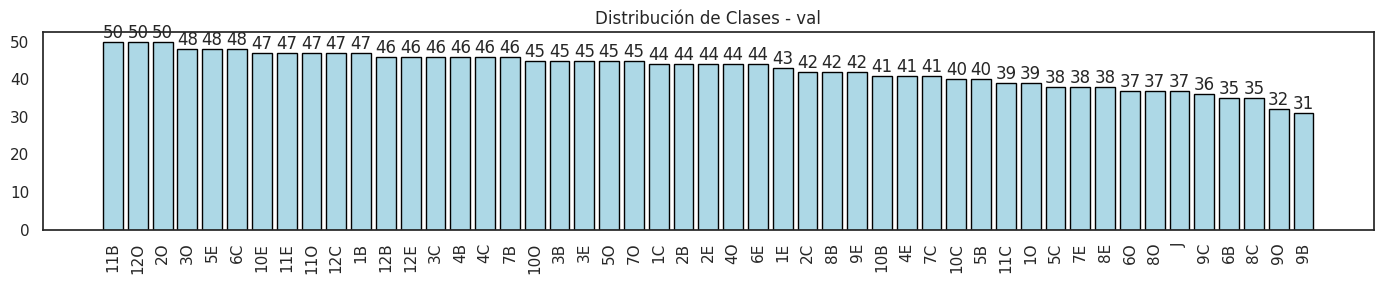

In [ ]:
invalid_files = []

# Contar las clases en las carpetas
class_counts_train = count_classes_in_folder(train_labels_path, train_images_path)
class_counts_val = count_classes_in_folder(val_labels_path, val_images_path)

# Graficar los resultados
plot_class_distribution(class_counts_train, "Distribución de Clases - train", color='lightgreen')
plot_class_distribution(class_counts_val, "Distribución de Clases - val", color='lightblue')

texto en negrita### Referencia

In [ ]:
%%writefile /content/dataset.yaml

train: /content/dataset/images/train
val: /content/dataset/images/val

nc: 49

names: [
    "1O", "1C", "1E", "1B",
    "2O", "2C", "2E", "2B",
    "3O", "3C", "3E", "3B",
    "4O", "4C", "4E", "4B",
    "5O", "5C", "5E", "5B",
    "6O", "6C", "6E", "6B",
    "7O", "7C", "7E", "7B",
    "8O", "8C", "8E", "8B",
    "9O", "9C", "9E", "9B",
    "10O", "10C", "10E", "10B",
    "11O", "11C", "11E", "11B",
    "12O", "12C", "12E", "12B",
    "J"
]

augmentation:
  hsv_h: 0.0
  hsv_s: 0.0
  hsv_v: 0.0
  degrees: 0.0
  translate: 0.0
  scale: 0.0
  shear: 0.0
  perspective: 0.0
  flipud: 0.0
  fliplr: 0.0
  mosaic: 0.0
  mixup: 0.0
  copy_paste: 0.0

Overwriting /content/dataset.yaml


## Aumentacion

### Primer aumentacion

#### Herramienta

In [6]:
import locale

locale.getpreferredencoding = lambda: "UTF-8"

In [7]:
!git clone https://github.com/muhammad-faizan-122/yolo-data-augmentation.git

Cloning into 'yolo-data-augmentation'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 230 (delta 81), reused 187 (delta 42), pack-reused 0
Receiving objects: 100% (230/230), 10.91 MiB | 15.06 MiB/s, done.
Resolving deltas: 100% (81/81), done.


#### Input

In [8]:
def clear_folder(path):
  shutil.rmtree(path)
  os.makedirs(path)

In [9]:
bb_image = "/content/yolo-data-augmentation/bb_image"
input_ds_images = "/content/yolo-data-augmentation/input-ds/images"
input_ds_labels = "/content/yolo-data-augmentation/input-ds/labels"
output_ds_images = "/content/yolo-data-augmentation/out-aug-ds/images"
output_ds_labels = "/content/yolo-data-augmentation/out-aug-ds/labels"

clear_folder(bb_image)
clear_folder(input_ds_images)
clear_folder(input_ds_labels)
clear_folder(output_ds_images)
clear_folder(output_ds_labels)

In [ ]:
def copy_files(source_folder, destination_folder):
    for filename in os.listdir(source_folder):
        file_path = os.path.join(source_folder, filename)
        if os.path.isfile(file_path):
            shutil.copy(file_path, destination_folder)

# copy_files(train_images_path, input_ds_images)
# copy_files(train_labels_path, input_ds_labels)

#### Referencias

In [10]:
%%writefile /content/yolo-data-augmentation/contants.yaml

inp_img_pth : /content/dataset/images/train
inp_lab_pth : /content/dataset/labels/train
out_img_pth : /content/yolo-data-augmentation/out-aug-ds/images
out_lab_pth : /content/yolo-data-augmentation/out-aug-ds/labels

transformed_file_name : aug_out

CLASSES : [
    "1O", "1C", "1E", "1B",
    "2O", "2C", "2E", "2B",
    "3O", "3C", "3E", "3B",
    "4O", "4C", "4E", "4B",
    "5O", "5C", "5E", "5B",
    "6O", "6C", "6E", "6B",
    "7O", "7C", "7E", "7B",
    "8O", "8C", "8E", "8B",
    "9O", "9C", "9E", "9B",
    "10O", "10C", "10E", "10B",
    "11O", "11C", "11E", "11B",
    "12O", "12C", "12E", "12B",
    "J"
]

augmentation_params:
  HorizontalFlip:
    p: 0.5
  ShiftScaleRotate:
    p: 0.5
  RandomBrightnessContrast:
    p: 0.3
  RGBShift:
    r_shift_limit: 30
    g_shift_limit: 30
    b_shift_limit: 30
    p: 0.3
  RandomSizedBBoxSafeCrop:
    width: 840
    height: 620
    erosion_rate: 0.2

Overwriting /content/yolo-data-augmentation/contants.yaml


#### Funciones

In [11]:
%%writefile /content/yolo-data-augmentation/utils.py

import albumentations as A
import cv2
import os
import yaml
import pybboxes as pbx


with open("/content/yolo-data-augmentation/contants.yaml", 'r') as stream:
    CONSTANTS = yaml.safe_load(stream)

augmentation_params = CONSTANTS['augmentation_params']


def is_image_by_extension(file_name):
    """
    Check if the given file has a recognized image extension.

    Args:
        file_name (str): Name of the file.

    Returns:
        bool: True if the file has a recognized image extension, False otherwise.

    """
    # List of common image extensions
    image_extensions = ['jpg', 'jpeg', 'png', 'gif', 'bmp', 'tiff', 'webp']
    # Get the file extension
    file_extension = file_name.lower().split('.')[-1]
    # Check if the file has a recognized image extension
    return file_extension in image_extensions


def get_inp_data(img_file):
    """
    Get input data for image processing.

    Args:
        img_file (str): Name of the input image file.

    Returns:
        tuple: A tuple containing the image, ground truth bounding boxes, and augmented file name.

    """
    file_name = os.path.splitext(img_file)[0]
    aug_file_name = f"{file_name}_{CONSTANTS['transformed_file_name']}"
    image = cv2.imread(os.path.join(CONSTANTS["inp_img_pth"], img_file))
    lab_pth = os.path.join(CONSTANTS["inp_lab_pth"], f"{file_name}.txt")
    gt_bboxes = get_bboxes_list(lab_pth, CONSTANTS['CLASSES'])
    return image, gt_bboxes, aug_file_name


def get_album_bb_list(yolo_bbox, class_names):
    """
    Extracts bounding box information for a single object from YOLO format.

    Args:
        yolo_bbox (str): YOLO format string representing bounding box information.
        class_names (list): List of class names corresponding to class numbers.

    Returns:
        list: A list containing [x_center, y_center, width, height, class_name].
    """
    str_bbox_list = yolo_bbox.split()
    class_number = int(str_bbox_list[0])
    class_name = class_names[class_number]
    bbox_values = list(map(float, str_bbox_list[1:]))
    album_bb = bbox_values + [class_name]
    return album_bb


def get_album_bb_lists(yolo_str_labels, classes):
    """
    Extracts bounding box information for multiple objects from YOLO format.

    Args:
        yolo_str_labels (str): YOLO format string containing bounding box information for multiple objects.
        classes (list): List of class names corresponding to class numbers.

    Returns:
        list: A list of lists, each containing [x_center, y_center, width, height, class_name].
    """
    album_bb_lists = []
    yolo_list_labels = yolo_str_labels.split('\n')
    for yolo_str_label in yolo_list_labels:
        if yolo_str_label:
            album_bb_list = get_album_bb_list(yolo_str_label, classes)
            album_bb_lists.append(album_bb_list)
    return album_bb_lists


def get_bboxes_list(inp_lab_pth, classes):
    """
    Reads YOLO format labels from a file and returns bounding box information.

    Args:
        inp_lab_pth (str): Path to the YOLO format labels file.
        classes (list): List of class names corresponding to class numbers.

    Returns:
        list: A list of lists, each containing [x_center, y_center, width, height, class_name].
    """
    yolo_str_labels = open(inp_lab_pth, "r").read()

    if not yolo_str_labels:
        print("No object")
        return []

    lines = [line.strip() for line in yolo_str_labels.split("\n") if line.strip()]
    album_bb_lists = get_album_bb_lists("\n".join(lines), classes) if len(lines) > 1 else [get_album_bb_list("\n".join(lines), classes)]

    return album_bb_lists


def single_obj_bb_yolo_conversion(transformed_bboxes, class_names):
    """
    Convert bounding boxes for a single object to YOLO format.

    Parameters:
    - transformed_bboxes (list): Bounding box coordinates and class name.
    - class_names (list): List of class names.

    Returns:
    - list: Bounding box coordinates in YOLO format.
    """
    if transformed_bboxes:
        class_num = class_names.index(transformed_bboxes[-1])
        bboxes = list(transformed_bboxes)[:-1]
        bboxes.insert(0, class_num)
    else:
        bboxes = []
    return bboxes


def multi_obj_bb_yolo_conversion(aug_labs, class_names):
    """
    Convert bounding boxes for multiple objects to YOLO format.

    Parameters:
    - aug_labs (list): List of bounding box coordinates and class names.
    - class_names (list): List of class names.

    Returns:
    - list: List of bounding box coordinates in YOLO format for each object.
    """
    yolo_labels = [single_obj_bb_yolo_conversion(aug_lab, class_names) for aug_lab in aug_labs]
    return yolo_labels


def save_aug_lab(transformed_bboxes, lab_pth, lab_name):
    """
    Save augmented bounding boxes to a label file.

    Args:
        transformed_bboxes (list): List of augmented bounding boxes.
        lab_pth (str): Path to the output label directory.
        lab_name (str): Name of the label file.

    """
    lab_out_pth = os.path.join(lab_pth, lab_name)
    with open(lab_out_pth, 'w') as output:
        for bbox in transformed_bboxes:
            updated_bbox = str(bbox).replace(',', ' ').replace('[', '').replace(']', '')
            output.write(updated_bbox + '\n')


def save_aug_image(transformed_image, out_img_pth, img_name):
    """
    Save augmented image to an output directory.

    Args:
        transformed_image (numpy.ndarray): Augmented image.
        out_img_pth (str): Path to the output image directory.
        img_name (str): Name of the image file.

    """
    out_img_path = os.path.join(out_img_pth, img_name)
    cv2.imwrite(out_img_path, transformed_image)


def draw_yolo(image, labels, file_name):
    """
    Draw bounding boxes on an image based on YOLO format.

    Args:
        image (numpy.ndarray): Input image.
        labels (list): List of bounding boxes in YOLO format.

    """
    H, W = image.shape[:2]
    for label in labels:
        yolo_normalized = label[1:]
        box_voc = pbx.convert_bbox(tuple(yolo_normalized), from_type="yolo", to_type="voc", image_size=(W, H))
        cv2.rectangle(image, (box_voc[0], box_voc[1]),
                      (box_voc[2], box_voc[3]), (0, 0, 255), 1)
    cv2.imwrite(f"/content/yolo-data-augmentation/bb_image/{file_name}.png", image)
    # cv2.imshow(f"{file_name}.png", image)
    # cv2.waitKey(0)


def has_negative_element(lst):
    """
    Check if the given list contains any negative element.

    Args:
        lst (list): List of elements.

    Returns:
        bool: True if there is any negative element, False otherwise.
    """
    return any(x < 0 for x in lst)

def has_negative_element(matrix):
    """
    Check if there is a negative element in the 2D list of augmented bounding boxes.

    Args:
        matrix (list[list]): The 2D list.

    Returns:
        bool: True if a negative element is found, False otherwise.

    """
    return any(element < 0 for row in matrix for element in row)


def save_augmentation(trans_image, trans_bboxes, trans_file_name):
    """
    Saves the augmented label and image if no negative elements are found in the transformed bounding boxes.

    Parameters:
        trans_image (numpy.ndarray): The augmented image.
        trans_bboxes (list): The transformed bounding boxes.
        trans_file_name (str): The name for the augmented output.

    Returns:
        None
    """
    tot_objs = len(trans_bboxes)
    if tot_objs:
        # Convert bounding boxes to YOLO format
        trans_bboxes = multi_obj_bb_yolo_conversion(trans_bboxes, CONSTANTS['CLASSES']) if tot_objs > 1 else [single_obj_bb_yolo_conversion(trans_bboxes[0], CONSTANTS['CLASSES'])]
        if not has_negative_element(trans_bboxes):
            # Save augmented label and image
            save_aug_lab(trans_bboxes, CONSTANTS["out_lab_pth"], trans_file_name + ".txt")
            save_aug_image(trans_image, CONSTANTS["out_img_pth"], trans_file_name + ".png")
            # Draw bounding boxes on the augmented image
            draw_yolo(trans_image, trans_bboxes, trans_file_name)
        else:
            print("Found Negative element in Transformed Bounding Box...")
    else:
        print("Label file is empty")


Overwriting /content/yolo-data-augmentation/utils.py


In [12]:
def get_augmented_results(image, bboxes):
    """
    Apply data augmentation to an input image and bounding boxes.

    Parameters:
    - image (numpy.ndarray): Input image.
    - bboxes (list): List of bounding boxes in YOLO format [x_center, y_center, width, height, class_name].

    Returns:
    - tuple: A tuple containing the augmented image and the transformed bounding boxes.
    """
    # Define the augmentations using the parameters from the YAML file
    transform = A.Compose([
        A.HorizontalFlip(p=augmentation_params['HorizontalFlip']['p']),
        A.ShiftScaleRotate(p=augmentation_params['ShiftScaleRotate']['p']),
        A.RandomBrightnessContrast(p=augmentation_params['RandomBrightnessContrast']['p']),
        A.RGBShift(r_shift_limit=augmentation_params['RGBShift']['r_shift_limit'],
                   g_shift_limit=augmentation_params['RGBShift']['g_shift_limit'],
                   b_shift_limit=augmentation_params['RGBShift']['b_shift_limit'],
                   p=augmentation_params['RGBShift']['p']),
        A.RandomSizedBBoxSafeCrop(width=augmentation_params['RandomSizedBBoxSafeCrop']['width'],
                                  height=augmentation_params['RandomSizedBBoxSafeCrop']['height'],
                                  erosion_rate=augmentation_params['RandomSizedBBoxSafeCrop']['erosion_rate'])
    ], bbox_params=A.BboxParams(format='yolo'))

    # Apply the augmentations
    transformed = transform(image=image, bboxes=bboxes)
    transformed_image, transformed_bboxes = transformed['image'], transformed['bboxes']

    return transformed_image, transformed_bboxes

#### Procesamiento

In [13]:
sys.path.append('/content/yolo-data-augmentation')
from utils import *

In [14]:
def run_yolo_augmentor():
    """
    Run the YOLO augmentor on a set of images.

    This function processes each image in the input directory, applies augmentations,
    and saves the augmented images and labels to the output directories.
    """
    imgs = [img for img in os.listdir(CONSTANTS["inp_img_pth"]) if is_image_by_extension(img)]

    for img_num, img_file in enumerate(imgs):
        print(f"{img_num + 1} - image is processing...")

        try:
            image, gt_bboxes, aug_file_name = get_inp_data(img_file)
            aug_img, aug_label = get_augmented_results(image, gt_bboxes)
            if len(aug_img) and len(aug_label):
                save_augmentation(aug_img, aug_label, aug_file_name)

        except Exception as e:
            print(f"Error: {e}")
            # Remove the problematic image and label files
            label_file = img_file.replace('.png', '.txt')  # Assuming .png extension, modify if necessary
            img_path = os.path.join(CONSTANTS["inp_img_pth"], img_file)
            label_path = os.path.join(CONSTANTS["inp_lab_pth"], label_file)

            try:
                if os.path.exists(img_path):
                    os.remove(img_path)
                    print(f"Removed image file: {img_path}")
                if os.path.exists(label_path):
                    os.remove(label_path)
                    print(f"Removed label file: {label_path}")
            except OSError as remove_error:
                print(f"Error removing files: {remove_error}")

            continue

In [ ]:
run_yolo_augmentor()

#### Counters

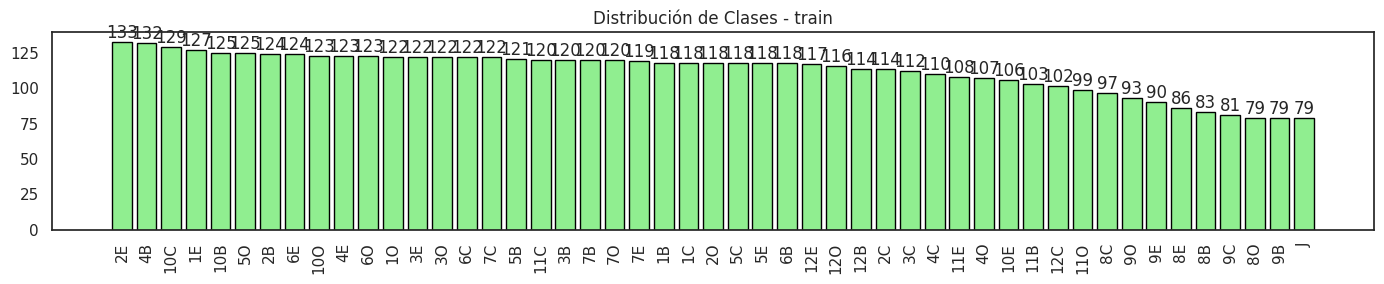

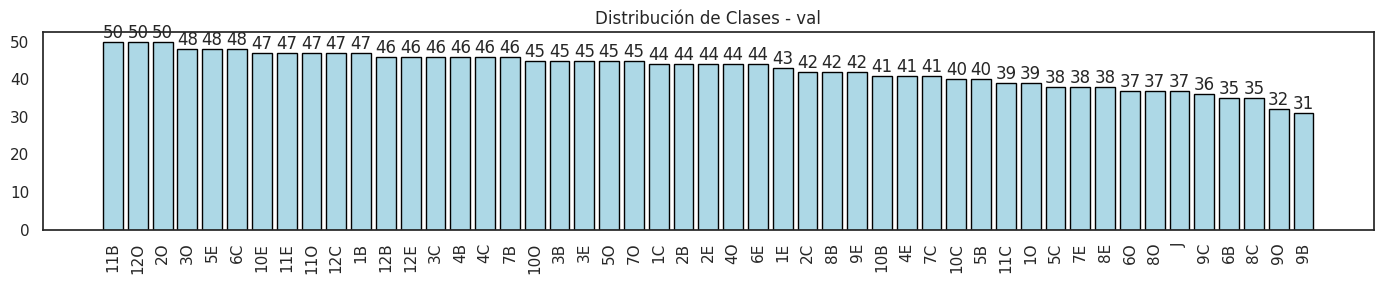

In [ ]:
invalid_files = []

# Contar las clases en las carpetas
class_counts_train = count_classes_in_folder(train_labels_path, train_images_path)
class_counts_val = count_classes_in_folder(val_labels_path, val_images_path)

# Graficar los resultados
plot_class_distribution(class_counts_train, "Distribución de Clases - train", color='lightgreen')
plot_class_distribution(class_counts_val, "Distribución de Clases - val", color='lightblue')

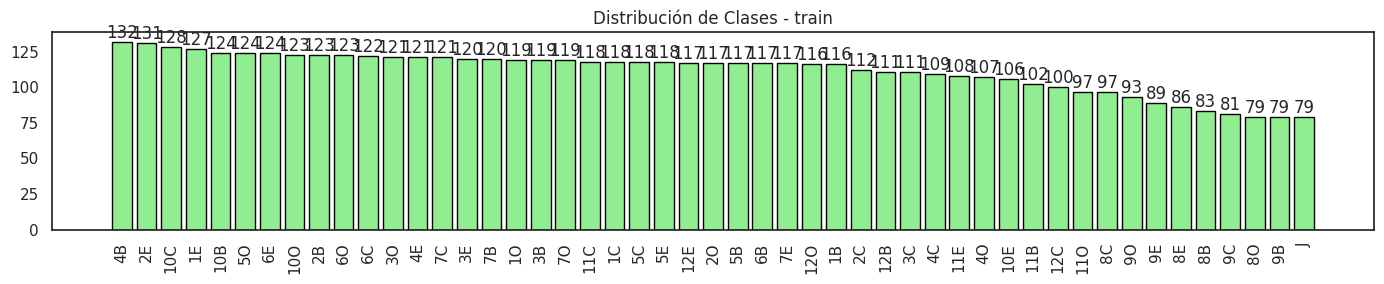

In [ ]:
invalid_files = []

class_counts_train = count_classes_in_folder(output_ds_labels, output_ds_images)
plot_class_distribution(class_counts_train, "Distribución de Clases - train", color='lightgreen')

In [ ]:
folder_path = '/content/dataset'
zip_path = '/content/drive/MyDrive/carta_base.zip'

# Remove the zip file if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Removed existing zip file: {zip_path}")

# Create a zip file from the folder
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=folder_path)

print(f"Folder has been zipped and saved to {zip_path}")

# List files in the destination directory to verify
destination_directory = '/content/drive/MyDrive'
print("Files in destination directory:")
for file_name in os.listdir(destination_directory):
    print(file_name)

Removed existing zip file: /content/drive/MyDrive/carta_base.zip
Folder has been zipped and saved to /content/drive/MyDrive/carta_base.zip
Files in destination directory:
carta_base.zip
Colab Notebooks


In [ ]:
folder_path = '/content/yolo-data-augmentation/out-aug-ds'
zip_path = '/content/drive/MyDrive/carta_aug_zip.zip'

# Remove the zip file if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Removed existing zip file: {zip_path}")

# Create a zip file from the folder
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=folder_path)

print(f"Folder has been zipped and saved to {zip_path}")

# List files in the destination directory to verify
destination_directory = '/content/drive/MyDrive'
print("Files in destination directory:")
for file_name in os.listdir(destination_directory):
    print(file_name)

### Segunda aumentacion

#### referencia

In [24]:
clear_folder(output_ds_images)
clear_folder(output_ds_labels)

In [25]:
%%writefile /content/yolo-data-augmentation/contants2.yaml

inp_img_pth: /content/dataset/images/train
inp_lab_pth: /content/dataset/labels/train
out_base_pth: /content/yolo-data-augmentation/out-aug-ds
transformed_file_name: aug_out

CLASSES : [
    "1O", "1C", "1E", "1B",
    "2O", "2C", "2E", "2B",
    "3O", "3C", "3E", "3B",
    "4O", "4C", "4E", "4B",
    "5O", "5C", "5E", "5B",
    "6O", "6C", "6E", "6B",
    "7O", "7C", "7E", "7B",
    "8O", "8C", "8E", "8B",
    "9O", "9C", "9E", "9B",
    "10O", "10C", "10E", "10B",
    "11O", "11C", "11E", "11B",
    "12O", "12C", "12E", "12B",
    "J"
]

configs:
  - name: config1
    augmentation_params:
      HorizontalFlip:
        p: 0.3
      ShiftScaleRotate:
        p: 0.8
      RandomBrightnessContrast:
        p: 0.3
      RGBShift:
        r_shift_limit: 12
        g_shift_limit: 89
        b_shift_limit: 134
        p: 0.4
      RandomSizedBBoxSafeCrop:
        width: 920
        height: 640
        erosion_rate: 0.6

  - name: config2
    augmentation_params:
      HorizontalFlip:
        p: 0.7
      ShiftScaleRotate:
        p: 0.7
      RandomBrightnessContrast:
        p: 0.5
      RGBShift:
        r_shift_limit: 140
        g_shift_limit: 80
        b_shift_limit: 0
        p: 0.5
      RandomSizedBBoxSafeCrop:
        width: 700
        height: 900
        erosion_rate: 0.3

  - name: config3
    augmentation_params:
      HorizontalFlip:
        p: 0.8
      ShiftScaleRotate:
        p: 0.6
      RandomBrightnessContrast:
        p: 0.4
      RGBShift:
        r_shift_limit: 59
        g_shift_limit: 12
        b_shift_limit: 230
        p: 0.8
      RandomSizedBBoxSafeCrop:
        width: 960
        height: 740
        erosion_rate: 0.7

Overwriting /content/yolo-data-augmentation/contants2.yaml


#### Generacion multiple

In [26]:
# Load constants from YAML
with open('/content/yolo-data-augmentation/contants2.yaml', 'r') as stream:
    try:
        CONSTANTS = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [27]:
def get_augmented_results(image, bboxes, augmentation_params):
    """
    Apply data augmentation to an input image and bounding boxes.

    Parameters:
    - image (numpy.ndarray): Input image.
    - bboxes (list): List of bounding boxes in YOLO format [x_center, y_center, width, height, class_name].
    - augmentation_params (dict): Dictionary containing augmentation parameters.

    Returns:
    - tuple: A tuple containing the augmented image and the transformed bounding boxes.
    """
    transform = A.Compose([
        A.HorizontalFlip(p=augmentation_params['HorizontalFlip']['p']),
        A.ShiftScaleRotate(p=augmentation_params['ShiftScaleRotate']['p']),
        A.RandomBrightnessContrast(p=augmentation_params['RandomBrightnessContrast']['p']),
        A.RGBShift(r_shift_limit=augmentation_params['RGBShift']['r_shift_limit'],
                   g_shift_limit=augmentation_params['RGBShift']['g_shift_limit'],
                   b_shift_limit=augmentation_params['RGBShift']['b_shift_limit'],
                   p=augmentation_params['RGBShift']['p']),
        A.RandomSizedBBoxSafeCrop(width=augmentation_params['RandomSizedBBoxSafeCrop']['width'],
                                  height=augmentation_params['RandomSizedBBoxSafeCrop']['height'],
                                  erosion_rate=augmentation_params['RandomSizedBBoxSafeCrop']['erosion_rate'])
    ], bbox_params=A.BboxParams(format='yolo'))

    transformed = transform(image=image, bboxes=bboxes)
    transformed_image, transformed_bboxes = transformed['image'], transformed['bboxes']

    return transformed_image, transformed_bboxes

def run_yolo_augmentor():
    """
    Run the YOLO augmentor on a set of images for each configuration.

    This function processes each image in the input directory, applies augmentations
    based on each configuration, and saves the augmented images and labels to
    respective output directories.
    """
    imgs = [img for img in os.listdir(CONSTANTS["inp_img_pth"]) if is_image_by_extension(img)]

    for config in CONSTANTS['configs']:
        config_name = config['name']
        out_img_pth = os.path.join(CONSTANTS['out_base_pth'], f'images_{config_name}')
        out_lab_pth = os.path.join(CONSTANTS['out_base_pth'], f'labels_{config_name}')

        os.makedirs(out_img_pth, exist_ok=True)
        os.makedirs(out_lab_pth, exist_ok=True)

        for img_num, img_file in enumerate(imgs):
            print(f"{img_num + 1} - Image is processing...")

            try:
                image, gt_bboxes, aug_file_name = get_inp_data(img_file)
                aug_img, aug_label = get_augmented_results(image, gt_bboxes, config['augmentation_params'])

                if len(aug_img) and len(aug_label):
                    save_augmentation(aug_img, aug_label, aug_file_name,
                                      out_img_pth=out_img_pth, out_lab_pth=out_lab_pth)

            except Exception as e:
                print(f"Error: {e}")
                # Remove the problematic image and label files
                label_file = img_file.replace('.png', '.txt')  # Assuming .png extension, modify if necessary
                img_path = os.path.join(CONSTANTS["inp_img_pth"], img_file)
                label_path = os.path.join(CONSTANTS["inp_lab_pth"], label_file)

                try:
                    if os.path.exists(img_path):
                        os.remove(img_path)
                        print(f"Removed image file: {img_path}")
                    if os.path.exists(label_path):
                        os.remove(label_path)
                        print(f"Removed label file: {label_path}")
                except OSError as remove_error:
                    print(f"Error removing files: {remove_error}")

                continue

def save_augmentation(trans_image, trans_bboxes, trans_file_name, out_img_pth, out_lab_pth):
    """
    Saves the augmented label and image if no negative elements are found in the transformed bounding boxes.

    Parameters:
        trans_image (numpy.ndarray): The augmented image.
        trans_bboxes (list): The transformed bounding boxes.
        trans_file_name (str): The name for the augmented output.
        out_img_pth (str): Path to the output image directory.
        out_lab_pth (str): Path to the output label directory.

    Returns:
        None
    """
    tot_objs = len(trans_bboxes)
    if tot_objs:
        # Convert bounding boxes to YOLO format
        trans_bboxes = multi_obj_bb_yolo_conversion(trans_bboxes, CONSTANTS['CLASSES']) if tot_objs > 1 else [single_obj_bb_yolo_conversion(trans_bboxes[0], CONSTANTS['CLASSES'])]
        if not has_negative_element(trans_bboxes):
            # Save augmented label and image
            save_aug_lab(trans_bboxes, out_lab_pth, trans_file_name + ".txt")
            save_aug_image(trans_image, out_img_pth, trans_file_name + ".png")
        else:
            print("Found Negative element in Transformed Bounding Box...")
    else:
        print("Label file is empty")

In [28]:
run_yolo_augmentor()

1 - Image is processing...
2 - Image is processing...
3 - Image is processing...
4 - Image is processing...
5 - Image is processing...
6 - Image is processing...
7 - Image is processing...
8 - Image is processing...
9 - Image is processing...
10 - Image is processing...
11 - Image is processing...
12 - Image is processing...
13 - Image is processing...
14 - Image is processing...
15 - Image is processing...
16 - Image is processing...
17 - Image is processing...
18 - Image is processing...
19 - Image is processing...
20 - Image is processing...
21 - Image is processing...
22 - Image is processing...
23 - Image is processing...
24 - Image is processing...
25 - Image is processing...
26 - Image is processing...
27 - Image is processing...
28 - Image is processing...
29 - Image is processing...
30 - Image is processing...
31 - Image is processing...
32 - Image is processing...
33 - Image is processing...
34 - Image is processing...
35 - Image is processing...
36 - Image is processing...
3

#### Saving

In [30]:
# Define the base directory where augmented images and labels are stored
base_dir = '/content/yolo-data-augmentation/out-aug-ds'

# List of configurations (adjust as per your setup)
configurations = ['config1', 'config2', 'config3']

def move_folders(config_name):
    """
    Move image and label folders and reorganize them under a new dataset folder.

    Parameters:
        config_name (str): Name of the configuration.

    Returns:
        None
    """
    # Define paths
    images_src = os.path.join(base_dir, f'images_{config_name}')
    labels_src = os.path.join(base_dir, f'labels_{config_name}')
    dataset_dst = os.path.join(base_dir, f'dataset_{config_name}')

    # Create dataset directory if it doesn't exist
    os.makedirs(dataset_dst, exist_ok=True)

    # Move image and label folders to dataset directory
    shutil.move(images_src, os.path.join(dataset_dst, 'images'))
    shutil.move(labels_src, os.path.join(dataset_dst, 'labels'))

    print(f"Moved and reorganized folders for configuration '{config_name}'")


for config in configurations:
    move_folders(config)

Moved and reorganized folders for configuration 'config1'
Moved and reorganized folders for configuration 'config2'
Moved and reorganized folders for configuration 'config3'


In [ ]:
folder_path = '/content/yolo-data-augmentation/out-aug-ds'
zip_path = '/content/drive/MyDrive/carta_aug_zip.zip'

# Remove the zip file if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Removed existing zip file: {zip_path}")

# Create a zip file from the folder
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=folder_path)

print(f"Folder has been zipped and saved to {zip_path}")

# List files in the destination directory to verify
destination_directory = '/content/drive/MyDrive'
print("Files in destination directory:")
for file_name in os.listdir(destination_directory):
    print(file_name)

In [31]:
drive_folder = '/content/drive/MyDrive'
zip_paths = []

In [32]:
def create_and_save_zip(config_name):
    """
    Create zip file for dataset folder and save it to Google Drive.

    Parameters:
        config_name (str): Name of the configuration.

    Returns:
        None
    """
    # Define paths
    dataset_path = os.path.join(base_dir, f'dataset_{config_name}')
    zip_path = os.path.join(drive_folder, f'aug_{config_name}.zip')

    # Remove existing zip file if exists
    if os.path.exists(zip_path):
        os.remove(zip_path)
        print(f"Removed existing zip file: {zip_path}")

    # Create zip file
    shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=dataset_path)

    # Print confirmation
    print(f"Created and saved zip file for configuration '{config_name}' at: {zip_path}")

    # Add zip path to list for verification
    zip_paths.append(zip_path)


# Create and save zip files for each configuration
for config in configurations:
    create_and_save_zip(config)

Created and saved zip file for configuration 'config1' at: /content/drive/MyDrive/aug_configconfig1.zip
Created and saved zip file for configuration 'config2' at: /content/drive/MyDrive/aug_configconfig2.zip
Created and saved zip file for configuration 'config3' at: /content/drive/MyDrive/aug_configconfig3.zip


In [33]:
os.rename('/content/drive/MyDrive/carta_aug_zip.zip', '/content/drive/MyDrive/aug_configconfigf0.zip')

In [34]:
os.rename('/content/drive/MyDrive/carta_base.zip', '/content/drive/MyDrive/original_dataset.zip')

In [36]:
# Define your base directory
base_dir = '/content/dataset'

# Define current and desired folder structure
current_structure = {
    'images': {
        'train': os.path.join(base_dir, 'images', 'train'),
        'val': os.path.join(base_dir, 'images', 'val')
    },
    'labels': {
        'train': os.path.join(base_dir, 'labels', 'train'),
        'val': os.path.join(base_dir, 'labels', 'val')
    }
}

desired_structure = {
    'train': {
        'images': os.path.join(base_dir, 'train', 'images'),
        'labels': os.path.join(base_dir, 'train', 'labels')
    },
    'val': {
        'images': os.path.join(base_dir, 'val', 'images'),
        'labels': os.path.join(base_dir, 'val', 'labels')
    }
}

# Create directories if they don't exist
for set_type, folders in desired_structure.items():
    for folder_type, path in folders.items():
        os.makedirs(path, exist_ok=True)

# Function to move files
def move_files(source_dir, dest_dir):
    files = os.listdir(source_dir)
    for file in files:
        source_path = os.path.join(source_dir, file)
        dest_path = os.path.join(dest_dir, file)
        shutil.move(source_path, dest_path)

# Move images and labels for train set
move_files(current_structure['images']['train'], desired_structure['train']['images'])
move_files(current_structure['labels']['train'], desired_structure['train']['labels'])

# Move images and labels for val set
move_files(current_structure['images']['val'], desired_structure['val']['images'])
move_files(current_structure['labels']['val'], desired_structure['val']['labels'])

print("Folder reorganization completed successfully!")

Folder reorganization completed successfully!


In [37]:
os.remove('/content/drive/MyDrive/original_dataset.zip')

In [38]:
folder_path = '/content/dataset/train'
zip_path = '/content/drive/MyDrive/original_dataset_train.zip'

# Remove the zip file if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Removed existing zip file: {zip_path}")

# Create a zip file from the folder
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=folder_path)

print(f"Folder has been zipped and saved to {zip_path}")

# List files in the destination directory to verify
destination_directory = '/content/drive/MyDrive'
print("Files in destination directory:")
for file_name in os.listdir(destination_directory):
    print(file_name)

Folder has been zipped and saved to /content/drive/MyDrive/original_dataset_train.zip
Files in destination directory:
Colab Notebooks
aug_config0.zip
aug_config1.zip
aug_config2.zip
aug_config3.zip
original_dataset_train.zip
.ipynb_checkpoints


In [39]:
folder_path = '/content/dataset/val'
zip_path = '/content/drive/MyDrive/original_dataset_val.zip'

# Remove the zip file if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Removed existing zip file: {zip_path}")

# Create a zip file from the folder
shutil.make_archive(base_name=zip_path.replace('.zip', ''), format='zip', root_dir=folder_path)

print(f"Folder has been zipped and saved to {zip_path}")

# List files in the destination directory to verify
destination_directory = '/content/drive/MyDrive'
print("Files in destination directory:")
for file_name in os.listdir(destination_directory):
    print(file_name)

Folder has been zipped and saved to /content/drive/MyDrive/original_dataset_val.zip
Files in destination directory:
Colab Notebooks
aug_config0.zip
aug_config1.zip
aug_config2.zip
aug_config3.zip
original_dataset_train.zip
.ipynb_checkpoints
original_dataset_val.zip


### guardar files en otro storage

In [ ]:
# import shutil

# # Define the folder to be zipped and the output zip file path
# folder_to_zip = '/content/yolo-data-augmentation/out-aug-ds'
# zip_file_path = '/content/carta_aug_zip.zip'

# # Create a zip file
# shutil.make_archive(base_name=zip_file_path.replace('.zip', ''), format='zip', root_dir=folder_to_zip)
# print(f"Folder zipped as {zip_file_path}")

Folder zipped as /content/carta_aug_zip.zip


In [ ]:
# from google.colab import auth
# from googleapiclient.discovery import build
# from googleapiclient.http import MediaFileUpload

# # Authenticate and create the API client
# auth.authenticate_user()

# # Initialize the Google Drive API client
# service = build('drive', 'v3')

# # Define the folder ID of the public folder
# folder_id = '1ilmefoLeDVDmHOtElkbmjzlhJeo_kNk0'

# # Define the path to the zip file
# file_name = 'carta_aug_zip.zip'
# file_path = f'/content/{file_name}'

# # Upload the zip file to the public folder
# file_metadata = {
#     'name': file_name,
#     'parents': [folder_id]
# }
# media = MediaFileUpload(file_path, mimetype='application/zip')

# file = service.files().create(body=file_metadata, media_body=media, fields='id').execute()
# print(f"File uploaded with ID: {file.get('id')}")

# # Optionally, list files in the folder to verify
# results = service.files().list(q=f"'{folder_id}' in parents", fields="files(name)").execute()
# items = results.get('files', [])
# print("Files in folder:")
# for item in items:
#     print(item['name'])


File uploaded with ID: 1-KTrsnfM9h7EJtyfYAcmjfbIJQTPHl9-
Files in folder:
